# The plan

The plan to test how can we improve the performance of the simulation of the phase protocol. We shall try both simplifying the initializer and de-initializers for the secondary register, as well as trying out things other than the aer simulator like the estimators and the like.


In [11]:
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, random_statevector
import numpy as np
from qiskit.circuit.library import StatePreparation
from qiskit_encore.preparable_statevector import GenericQiskitPreparableStatevector

In [12]:
phi = random_statevector(64)
phi

Statevector([ 0.03741751-0.08339567j, -0.04822647-0.05566148j,
             -0.11204097+0.07477167j, -0.07227967+0.12560187j,
             -0.07357552+0.06251416j,  0.03517692+0.1039649j ,
             -0.11399478-0.16900572j,  0.08235813-0.08565555j,
             -0.00413968+0.14477925j, -0.11990792-0.02499587j,
              0.02875326+0.02249987j,  0.11511364-0.13674346j,
              0.18898319+0.06530325j,  0.06359397-0.08929915j,
             -0.18416931-0.10509789j,  0.00311835+0.08313241j,
              0.01419644+0.16141677j,  0.0606516 +0.0314772j ,
              0.02760941+0.03150851j,  0.05310838-0.07850299j,
             -0.03789591-0.08798333j,  0.07184163-0.1110862j ,
             -0.04847539-0.04473557j, -0.03499988-0.02027017j,
              0.00447388-0.15026061j, -0.05190821+0.12998018j,
              0.10210475+0.06137277j, -0.00507051-0.06863452j,
             -0.09678656+0.09283349j,  0.19814501+0.00517417j,
             -0.17731424+0.1540261j , -0.01818641+0.148

In [13]:
prep = StatePreparation(phi)
de_prep = prep.inverse()

In [14]:
circ0 = QuantumCircuit(prep.num_qubits)
circ0.append(prep, circ0.qubits)
# circ0.draw()

In [15]:
output = Statevector.from_instruction(circ0)
np.allclose(output.data, phi.data)

True

In [16]:
circ0.append(de_prep, circ0.qubits)

In [17]:
output = Statevector.from_instruction(circ0)
output

Statevector([ 1.00000000e+00-1.42941214e-15j,
             -2.83452108e-16+1.54249938e-15j,
              4.28585726e-16+6.30421064e-16j,
              6.55096519e-16+3.22502370e-16j,
             -4.86624072e-16-3.47795390e-17j,
              4.87137042e-16-1.08420699e-16j,
             -1.51433802e-15+3.82691575e-16j,
             -3.86525100e-16-4.04922869e-16j,
              2.66164721e-16+7.88658694e-16j,
             -1.50635786e-16+1.47396689e-17j,
              7.91410881e-16-7.11488399e-16j,
              1.61765052e-16-1.41405002e-15j,
             -1.57646164e-16+6.69984862e-16j,
             -2.45671738e-16+4.70335636e-16j,
              2.44991418e-16+1.05354054e-15j,
              3.87919064e-16+3.55240068e-16j,
              8.54120796e-17-4.54794902e-16j,
             -1.22027679e-15+5.74149655e-16j,
             -1.23797988e-15-5.20363058e-16j,
             -1.21782336e-16+1.01459803e-15j,
              1.24040521e-16-1.63088554e-16j,
             -4.81896932e-16-7.088

In [18]:
prepable = GenericQiskitPreparableStatevector.from_statevector(phi)

Using generic qiskit state initializer.
qiskit inverse de-initializer


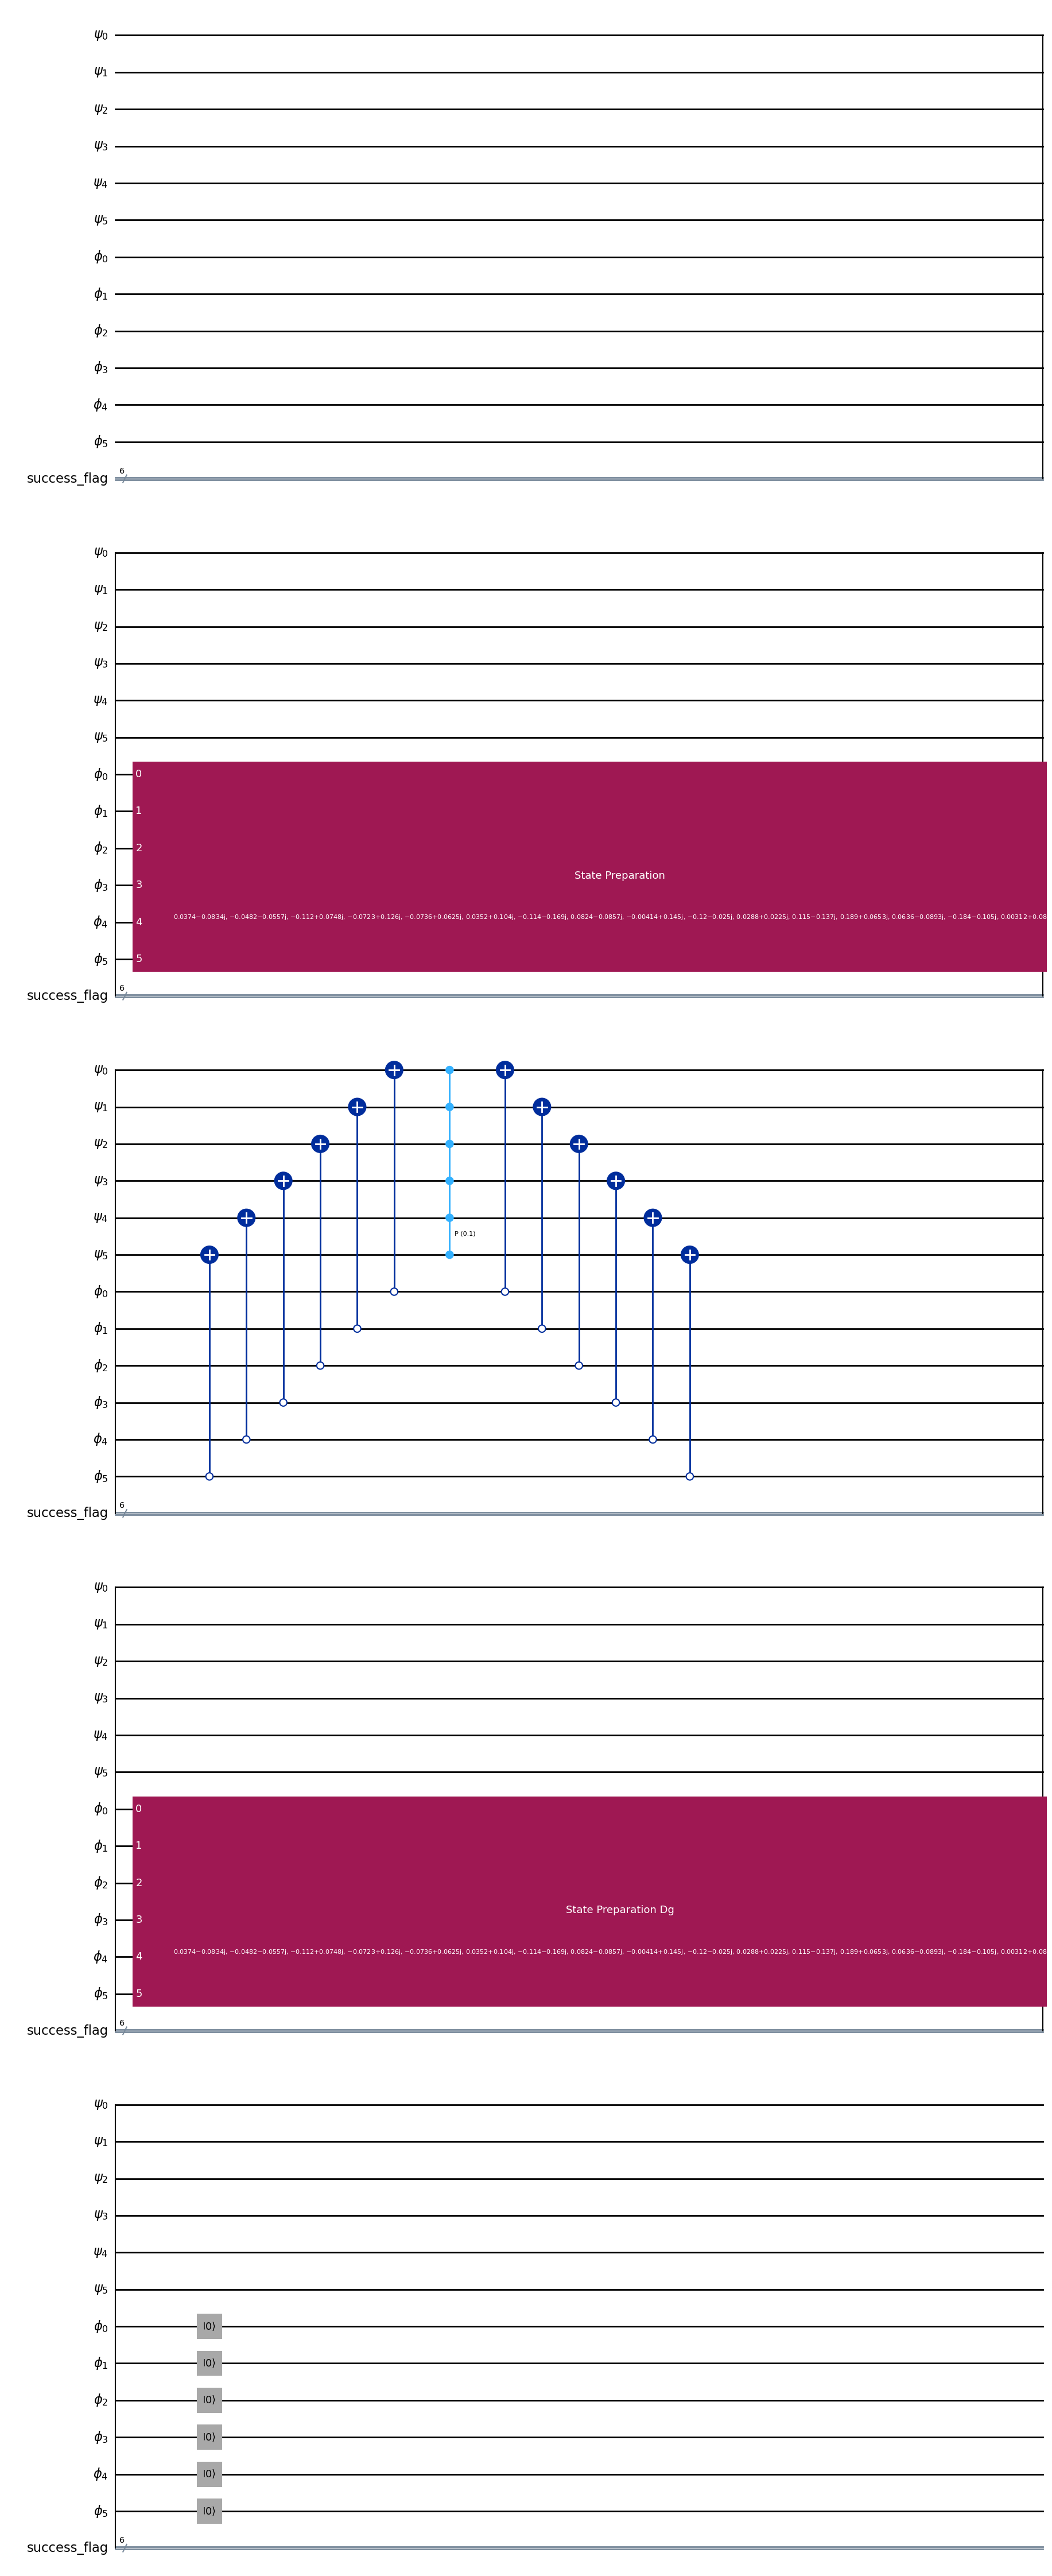

In [19]:
from qiskit_phase_propagator.sample_based import (
    GenericIterativeSampleBasedPhasePropagatorWithAllClassicalRegisters,
)

delta = 0.1

circ2 = GenericIterativeSampleBasedPhasePropagatorWithAllClassicalRegisters.from_state(
    prepable, [delta]
)

circ2.draw("mpl")

In [20]:
output = Statevector.from_instruction(circ2)
output

Statevector([0.99999965+0.00083413j, 0.        +0.j        ,
             0.        +0.j        , ..., 0.        +0.j        ,
             0.        +0.j        , 0.        +0.j        ],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
